In [1]:
%load_ext autoreload
%autoreload 2                                   

In [2]:
from src.utils.utils import find_project_root, load_ligand_models

BASE_DIR = find_project_root()

DATA_DIR = BASE_DIR / "data" / "processed" 

from figures.fig_scripts.fig1_functions import *
from src.analysis.Ligand4PL import FourPLGeneModel

/home/labs/antebilab/guyilan/.conda/envs/paper_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading Noramlized KS-FDR filtered data frame

In [3]:
df = pd.read_parquet(DATA_DIR / "cpm_df.parquet")

### Generating processed BMP4 object

In [4]:
bmp4_model = FourPLGeneModel(
    "BMP4",
    df,
)

Initializing FourPLGeneModel for BMP4...
Function get_significant_genes Took 0.0175 seconds
Function run_fitted_pca Took 0.0057 seconds
Function fit_pc1_to_4pl Took 0.0022 seconds
Function generate_all_genes_params Took 14.0265 seconds
Function get_pb_fc_values Took 0.0773 seconds


### Panel A:

Cartoon Data

### Panel B: BMP4 significant genes count per concentration level

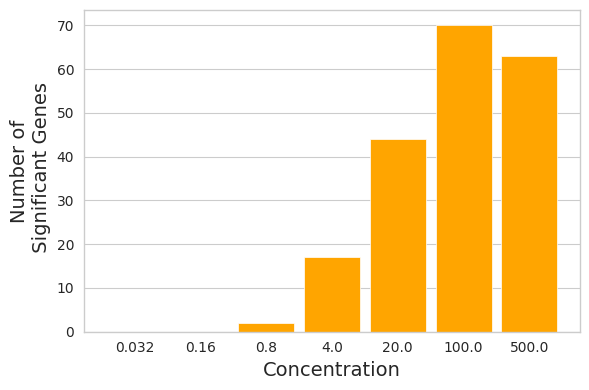

In [16]:
plot_fdr_gene_counts("BMP4", bmp4_model.sig_df, save=True)

### Panel C: BMP4 responsive genes log2FC across concentrations

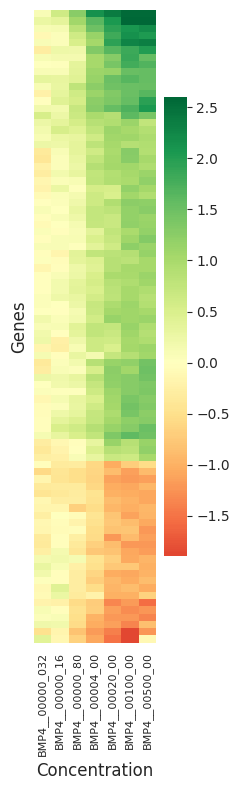

In [17]:
reordered_data, gene_order = cluster_heatmap_data(bmp4_model.df_fc_ligand_sig, reverse_order=True)
plot_heatmap("BMP4", reordered_data, save=True)

### Panel D: BMP4 significant genes correlation matrix

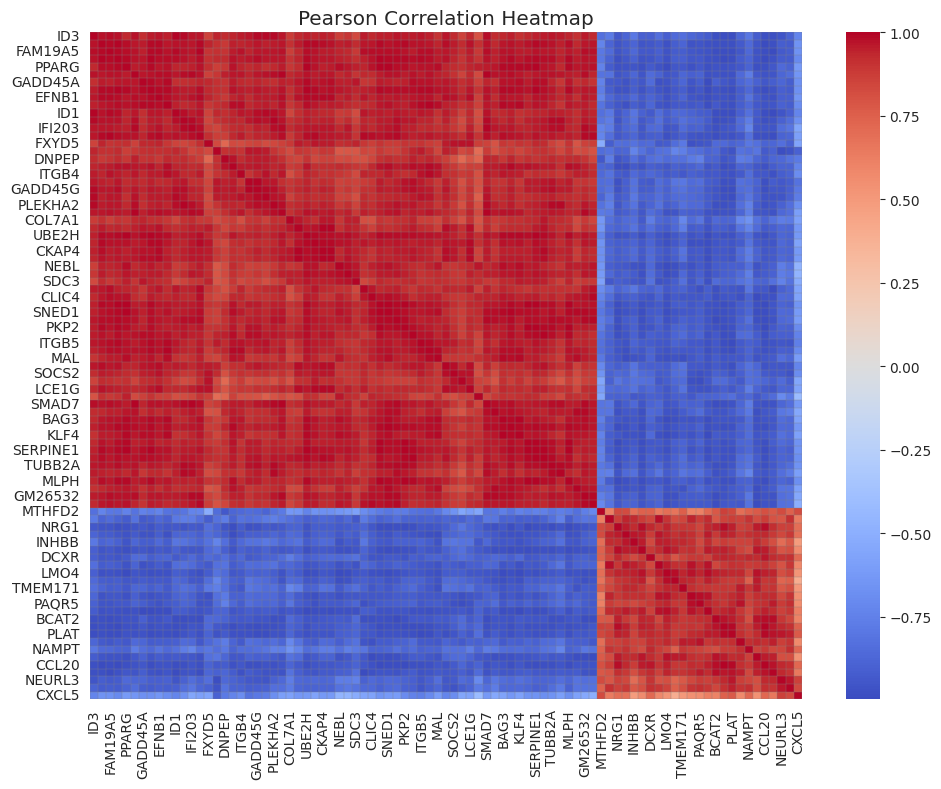

In [18]:
plot_corr_heatmap(bmp4_model.df_fc_ligand_sig, gene_order, method="pearson", save=True)

### Panel E: BMP4 responsive genes normalized response curves

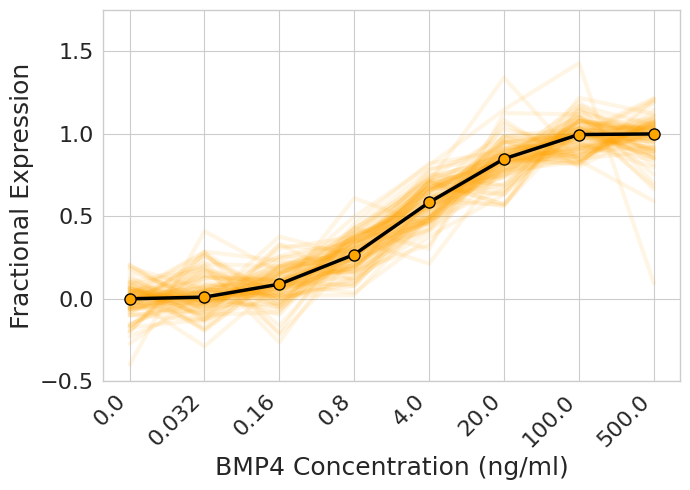

In [19]:
plot_fractional_expression(
    "BMP4",
    bmp4_model.norm_exp_all_genes[bmp4_model.ligand_sig_genes_from_dict],
    bmp4_model.concentrations,
    save=True,
    plot_median=True,
)

### Panel F: BMP4 population level PCA

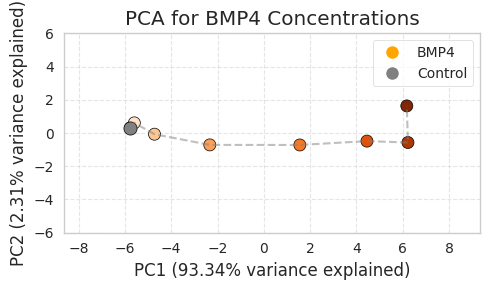

In [20]:
plot_mean_pca("BMP4", bmp4_model, save=True)